In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pyarrow.feather as feather

# Load the feather file (bypasses pandas/pyarrow compatibility bug)
df = feather.read_table('lending_club_clean.feather').to_pandas()

# Quick check
print(f"Shape: {df.shape}")
print(f"\nColumns: {df.columns.tolist()[:10]}...")  # First 10 columns
print(f"\nFirst few rows of int_rate:")
print(df['int_rate'].head(10))

Shape: (2925492, 141)

Columns: ['id', 'loan_amnt', 'funded_amnt', 'funded_amnt_inv', 'term', 'int_rate', 'installment', 'grade', 'sub_grade', 'emp_title']...

First few rows of int_rate:
0    0.1065
1    0.1527
2    0.1596
3    0.1349
4    0.1269
5    0.0790
6    0.1596
7    0.1864
8    0.2128
9    0.1269
Name: int_rate, dtype: float32


In [2]:
# 1. DATASET OVERVIEW
print("=" * 60)
print("1. DATASET SHAPE")
print("=" * 60)
print(f"Rows: {df.shape[0]:,}")
print(f"Columns: {df.shape[1]}")

#block
# 2. Variable type breakdown
#block
print("\n" + "=" * 60)
print("2. VARIABLE TYPE BREAKDOWN")
print("=" * 60)
dtype_counts = df.dtypes.astype(str).value_counts()
print(dtype_counts)

# 3. int_rate descriptive statistics
print("\n" + "=" * 60)
print("3. int_rate DESCRIPTIVE STATISTICS")
print("=" * 60)
int_rate_pct = df['int_rate'] * 100  # convert to percentage
print(int_rate_pct.describe())
print(f"\nInterest rate ranges from {int_rate_pct.min():.2f}% to {int_rate_pct.max():.2f}%")

# 4. All column names grouped by dtype (using string repr)
print("\n" + "=" * 60)
print("4. ALL COLUMN NAMES GROUPED BY DTYPE")
print("=" * 60)
dtype_strings = df.dtypes.astype(str)
for dtype_name in sorted(dtype_strings.unique()):
    cols = dtype_strings[dtype_strings == dtype_name].index.tolist()
    print(f"\n--- {dtype_name} ({len(cols)} columns) ---")
    for col in cols:
        print(f"  {col}")

# 5. Key column statistics
cols_to_inspect = [
    'fico_range_low', 'fico_range_high', 'annual_inc', 'dti',
    'loan_amnt', 'term', 'purpose', 'emp_length', 'home_ownership',
    'delinq_2yrs', 'revol_util', 'open_acc', 'pub_rec', 'revol_bal',
    'mort_acc', 'pub_rec_bankruptcies', 'verification_status',
    'addr_state', 'application_type'
]

print("\n" + "=" * 60)
print("5. DESCRIBE & VALUE_COUNTS FOR KEY COLUMNS")
print("=" * 60)
for col in cols_to_inspect:
    if col not in df.columns:
        print(f"\n  *** {col} NOT FOUND ***")
        continue
    print(f"\n{'─' * 50}")
    print(f"  Column: {col}  |  dtype: {df[col].dtype}  |  nulls: {df[col].isnull().sum():,}")
    print(f"{'─' * 50}")
    try:
        print(df[col].describe())
    except Exception:
        print(f"  unique: {df[col].nunique()}, top: {df[col].mode().iloc[0] if len(df[col].mode()) > 0 else 'N/A'}")
    print(f"\nValue counts (top 10):")
    print(df[col].value_counts().head(10))

# 6. Missing values — top 30
print("\n" + "=" * 60)
print("6. MISSING VALUES (top 30 columns)")
print("=" * 60)
missing = df.isnull().sum().sort_values(ascending=False)
print(missing.head(30))
print(f"\nTotal columns with any missing: {(missing > 0).sum()}")

#block
# 7. annual_inc percentiles
#block
print("\n" + "=" * 60)
print("7. annual_inc PERCENTILES")
print("=" * 60)
percentiles = [0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99, 1.0]
print(df['annual_inc'].quantile(percentiles))


1. DATASET SHAPE
Rows: 2,925,492
Columns: 141

2. VARIABLE TYPE BREAKDOWN
Int16             54
float32           26
category          22
Int64             15
Int32             15
datetime64[ns]     9
Name: count, dtype: int64

3. int_rate DESCRIPTIVE STATISTICS
count    2.925492e+06
mean     1.304545e+01
std      4.860815e+00
min      5.310000e+00
25%      9.170000e+00
50%      1.249000e+01
75%      1.599000e+01
max      3.099000e+01
Name: int_rate, dtype: float64

Interest rate ranges from 5.31% to 30.99%

4. ALL COLUMN NAMES GROUPED BY DTYPE

--- Int16 (54 columns) ---
  term
  delinq_2yrs
  inq_last_6mths
  mths_since_last_delinq
  mths_since_last_record
  open_acc
  pub_rec
  total_acc
  collections_12_mths_ex_med
  mths_since_last_major_derog
  policy_code
  acc_now_delinq
  open_acc_6m
  open_act_il
  open_il_12m
  open_il_24m
  open_rv_12m
  open_rv_24m
  all_util
  inq_fi
  total_cu_tl
  inq_last_12m
  acc_open_past_24mths
  chargeoff_within_12_mths
  mort_acc
  mths_since_rece

In [3]:
# Missing values — rows perspective (how many rows have any missing data)
print("\n" + "=" * 60)
print("ROWS WITH MISSING DATA")
print("=" * 60)

# Count missing values per row
missing_per_row = df.isnull().sum(axis=1)

# Statistics
rows_with_missing = (missing_per_row > 0).sum()
rows_complete = (missing_per_row == 0).sum()
total_rows = len(df)

print(f"Total rows: {total_rows:,}")
print(f"Rows with at least one missing value: {rows_with_missing:,} ({rows_with_missing/total_rows*100:.1f}%)")
print(f"Completely filled rows (no missing): {rows_complete:,} ({rows_complete/total_rows*100:.1f}%)")
print(f"\nMissing values per row statistics:")
print(f"  Min: {missing_per_row.min()}")
print(f"  Max: {missing_per_row.max()}")
print(f"  Mean: {missing_per_row.mean():.2f}")
print(f"  Median: {missing_per_row.median():.0f}")

# Show distribution of rows by number of missing values
print(f"\nDistribution of rows by number of missing columns:")
missing_dist = missing_per_row.value_counts().sort_index()
for num_missing, count in missing_dist.items():
    if num_missing <= 10 or num_missing % 5 == 0:  # Show first 10 and then every 5th
        print(f"  {num_missing} missing columns: {count:>7,} rows ({count/total_rows*100:.1f}%)")



ROWS WITH MISSING DATA
Total rows: 2,925,492
Rows with at least one missing value: 2,910,868 (99.5%)
Completely filled rows (no missing): 14,624 (0.5%)

Missing values per row statistics:
  Min: 0
  Max: 14
  Mean: 9.34
  Median: 10

Distribution of rows by number of missing columns:
  0 missing columns:  14,624 rows (0.5%)
  1 missing columns:   3,402 rows (0.1%)
  2 missing columns: 100,637 rows (3.4%)
  3 missing columns:  20,159 rows (0.7%)
  4 missing columns:   4,155 rows (0.1%)
  5 missing columns:     615 rows (0.0%)
  6 missing columns:      46 rows (0.0%)
  7 missing columns:  83,880 rows (2.9%)
  8 missing columns:  64,054 rows (2.2%)
  9 missing columns: 722,871 rows (24.7%)
  10 missing columns: 1,694,708 rows (57.9%)


MISSING DATA ANALYSIS: 21 PREDICTOR VARIABLES

Total rows in dataset: 2,925,492

Column                           Missing Count  Percentage
──────────────────────────────────────────────────────────────────────
  emp_length                           205,220        7.0%
  revol_util                             2,660        0.1%
  earliest_cr_line                          29        0.0%

ROWS PERSPECTIVE

Total rows: 2,925,492
  ✓ Completely filled (no missing):        2,717,861 ( 92.9%)
  ✗ At least one missing value:              207,631 (  7.1%)

Missing values per row statistics:
  Min per row: 0
  Max per row: 2
  Mean per row: 0.07
  Median per row: 0


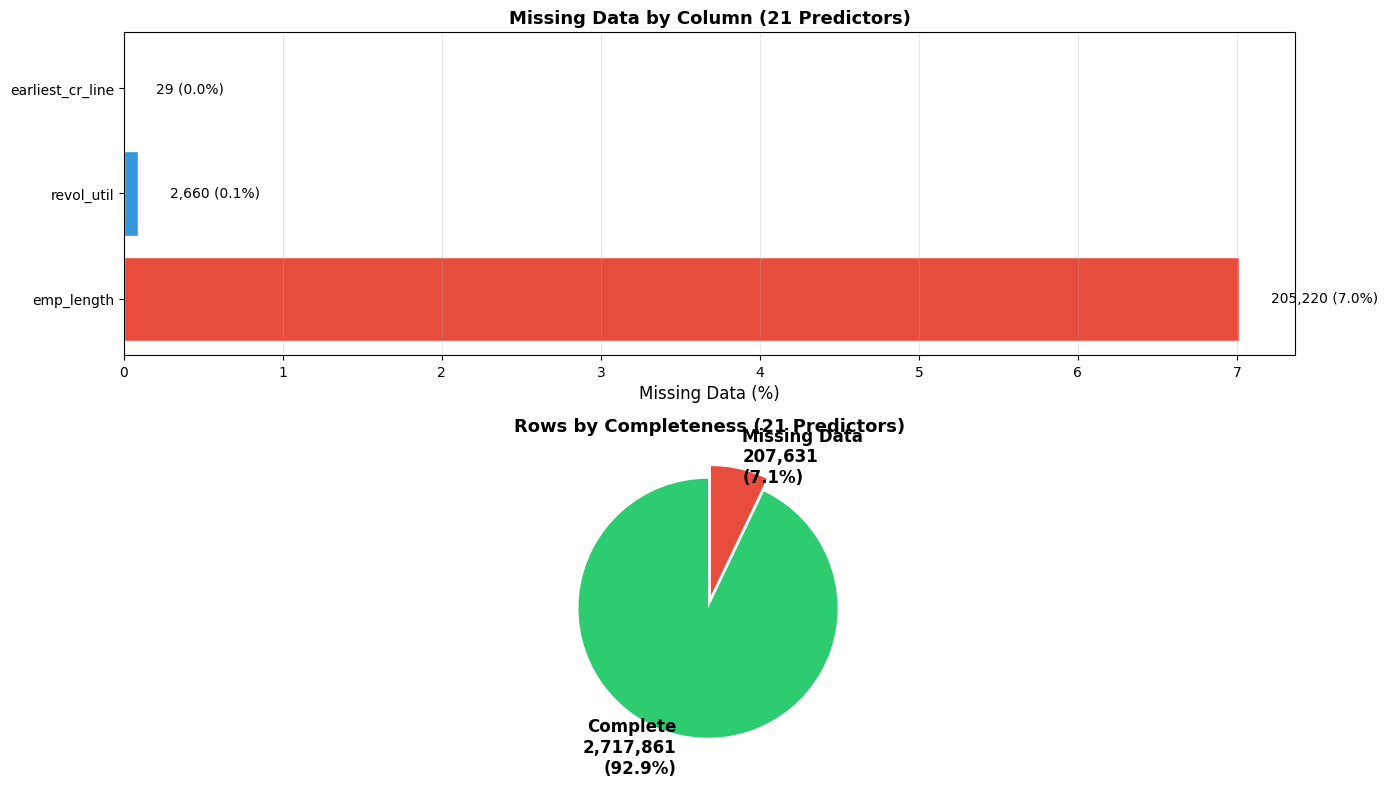


✓ Visualization saved as 'missing_data_analysis.png'


In [4]:
#block
# MISSING VALUES ANALYSIS: 21 PREDICTOR VARIABLES
#block

# The 21 recommended predictor variables
predictors_21 = [
    'fico_range_low', 'fico_range_high', 'dti', 'delinq_2yrs', 
    'inq_last_6mths', 'open_acc', 'pub_rec', 'revol_bal', 'revol_util',
    'pub_rec_bankruptcies', 'mort_acc', 'earliest_cr_line', 'loan_amnt',
    'term', 'purpose', 'annual_inc', 'emp_length', 'home_ownership',
    'verification_status', 'application_type', 'addr_state'
]

print("=" * 70)
print("MISSING DATA ANALYSIS: 21 PREDICTOR VARIABLES")
print("=" * 70)
print(f"\nTotal rows in dataset: {len(df):,}\n")

subset = df[predictors_21]
missing_by_col = subset.isnull().sum().sort_values(ascending=False)

print(f"{'Column':<30} {'Missing Count':>15}  {'Percentage':>10}")
print("─" * 70)

for col, missing_count in missing_by_col.items():
    pct = 100 * missing_count / len(df)
    if missing_count > 0:
        print(f"  {col:<28} {missing_count:>15,}  {pct:>9.1f}%")

print("\n" + "=" * 70)
print("ROWS PERSPECTIVE")
print("=" * 70)

# How many rows have at least one missing value among these 21?
missing_per_row = subset.isnull().sum(axis=1)
rows_with_any_missing = (missing_per_row > 0).sum()
rows_complete = (missing_per_row == 0).sum()

print(f"\nTotal rows: {len(df):,}")
print(f"  ✓ Completely filled (no missing):     {rows_complete:>12,} ({100*rows_complete/len(df):>5.1f}%)")
print(f"  ✗ At least one missing value:         {rows_with_any_missing:>12,} ({100*rows_with_any_missing/len(df):>5.1f}%)")

print(f"\nMissing values per row statistics:")
print(f"  Min per row: {missing_per_row.min()}")
print(f"  Max per row: {missing_per_row.max()}")
print(f"  Mean per row: {missing_per_row.mean():.2f}")
print(f"  Median per row: {missing_per_row.median():.0f}")

# Visualization: missing data heatmap
fig, axes = plt.subplots(2, 1, figsize=(14, 8))

# Bar chart: missing counts
missing_to_plot = missing_by_col[missing_by_col > 0]
colors_bar = ['#e74c3c' if pct > 1 else '#f39c12' if pct > 0.1 else '#3498db' 
              for pct in 100 * missing_to_plot / len(df)]

axes[0].barh(range(len(missing_to_plot)), 100 * missing_to_plot / len(df), 
             color=colors_bar, edgecolor='white')
axes[0].set_yticks(range(len(missing_to_plot)))
axes[0].set_yticklabels(missing_to_plot.index)
axes[0].set_xlabel('Missing Data (%)', fontsize=12)
axes[0].set_title('Missing Data by Column (21 Predictors)', fontsize=13, fontweight='bold')
axes[0].grid(True, axis='x', alpha=0.3)

for i, (col, count) in enumerate(missing_to_plot.items()):
    pct = 100 * count / len(df)
    axes[0].text(pct + 0.2, i, f'{count:,} ({pct:.1f}%)', va='center', fontsize=10)

# Pie chart: rows with vs without missing
sizes = [rows_complete, rows_with_any_missing]
labels = [f'Complete\n{rows_complete:,}\n({100*rows_complete/len(df):.1f}%)',
          f'Missing Data\n{rows_with_any_missing:,}\n({100*rows_with_any_missing/len(df):.1f}%)']
colors_pie = ['#2ecc71', '#e74c3c']
explode = (0.05, 0.05)

axes[1].pie(sizes, labels=labels, colors=colors_pie, autopct='', explode=explode,
            startangle=90, textprops={'fontsize': 12, 'weight': 'bold'})
axes[1].set_title('Rows by Completeness (21 Predictors)', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.savefig('missing_data_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n✓ Visualization saved as 'missing_data_analysis.png'")


## Recommended Predictor Variables (15-20)

**Excluded (data leakage):** grade, sub_grade, installment, total_pymnt*, last_pymnt*, recoveries, hardship_*, collection_recovery_fee, funded_amnt, funded_amnt_inv

**Selected predictors** — features known at loan origination:

In [5]:

# RECOMMENDED PREDICTOR VARIABLES (known at origination)

recommended_predictors = {
    #Borrower Credit Profile 
    'fico_range_low':       'FICO credit score (lower bound)',
    'fico_range_high':      'FICO credit score (upper bound)',
    'dti':                  'Debt-to-income ratio',
    'delinq_2yrs':          'Delinquencies in past 2 years',
    'inq_last_6mths':       'Credit inquiries in last 6 months',
    'open_acc':             'Number of open credit lines',
    'pub_rec':              'Number of derogatory public records',
    'revol_bal':            'Total revolving balance ($)',
    'revol_util':           'Revolving utilization rate (%)',
    'pub_rec_bankruptcies': 'Number of public record bankruptcies',
    'mort_acc':             'Number of mortgage accounts',
    'earliest_cr_line':     'Date of earliest credit line (proxy for credit age)',
    
    #Loan Characteristics
    'loan_amnt':            'Loan amount requested ($)',
    'term':                 'Loan term (36 or 60 months)',
    'purpose':              'Purpose of the loan',
    
    #Borrower Demographics/Financial
    'annual_inc':           'Annual income ($)',
    'emp_length':           'Employment length (years)',
    'home_ownership':       'Home ownership status',
    'verification_status':  'Income verification status',
    'application_type':     'Individual vs Joint application',
    'addr_state':           'Borrower state (geographic risk)',
}

print(f"Total recommended predictors: {len(recommended_predictors)}\n")
print(f"{'Variable':<25} {'Description':<50} {'In Dataset?'}")
print("─" * 85)
for var, desc in recommended_predictors.items():
    exists = "YES" if var in df.columns else "NO"
    print(f"{var:<25} {desc:<50} {exists}")

# Check which are available
available = [v for v in recommended_predictors if v in df.columns]
print(f"\nAvailable in dataset: {len(available)} / {len(recommended_predictors)}")


Total recommended predictors: 21

Variable                  Description                                        In Dataset?
─────────────────────────────────────────────────────────────────────────────────────
fico_range_low            FICO credit score (lower bound)                    YES
fico_range_high           FICO credit score (upper bound)                    YES
dti                       Debt-to-income ratio                               YES
delinq_2yrs               Delinquencies in past 2 years                      YES
inq_last_6mths            Credit inquiries in last 6 months                  YES
open_acc                  Number of open credit lines                        YES
pub_rec                   Number of derogatory public records                YES
revol_bal                 Total revolving balance ($)                        YES
revol_util                Revolving utilization rate (%)                     YES
pub_rec_bankruptcies      Number of public record bankruptcies

---
## Visualizations: Predictors vs. Interest Rate

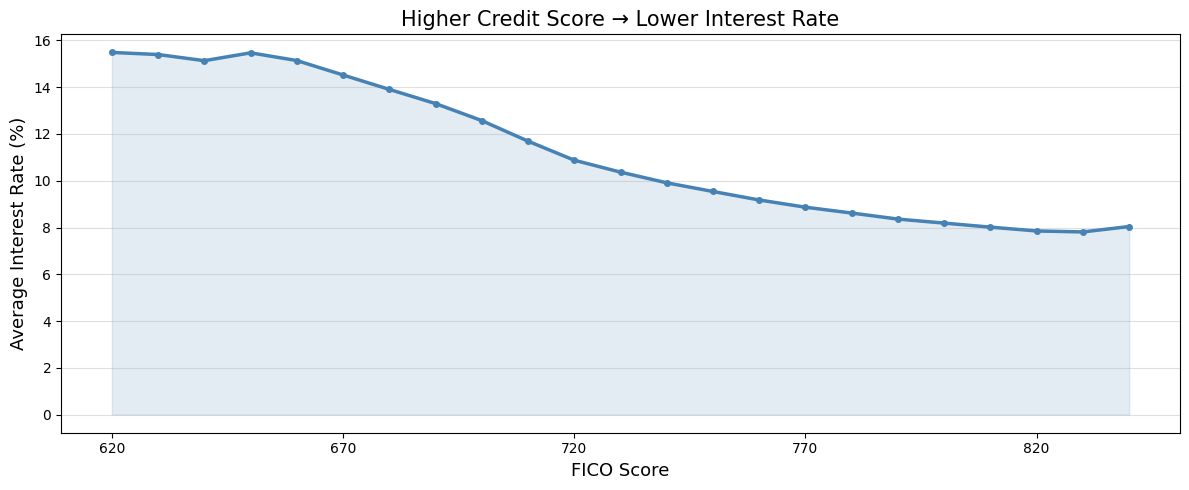

In [6]:

#block
# VIZ 1: FICO Score vs Interest Rate
# Bin FICO into groups, show average rate per group
plot_df = df[['fico_range_low', 'int_rate']].dropna().copy()
plot_df['int_rate_pct'] = plot_df['int_rate'] * 100

# Bin into 10-point FICO buckets, label them cleanly
plot_df['fico_bucket'] = pd.cut(plot_df['fico_range_low'],
                                bins=range(620, 860, 10),
                                labels=[str(x) for x in range(620, 850, 10)])

summary = plot_df.groupby('fico_bucket', observed=True)['int_rate_pct'].mean()

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(summary.index.astype(str), summary.values, color='steelblue', linewidth=2.5, marker='o', markersize=4)
ax.fill_between(range(len(summary)), summary.values, alpha=0.15, color='steelblue')

# Only label every 5th tick so x-axis isn't crowded
ticks = list(range(0, len(summary), 5))
ax.set_xticks(ticks)
ax.set_xticklabels([summary.index[i] for i in ticks], rotation=0)

ax.set_xlabel('FICO Score', fontsize=13)
ax.set_ylabel('Average Interest Rate (%)', fontsize=13)
ax.set_title('Higher Credit Score → Lower Interest Rate', fontsize=15)
ax.grid(True, axis='y', alpha=0.4)
plt.tight_layout()
plt.savefig('viz1_fico_vs_rate.png', dpi=150, bbox_inches='tight')
plt.show()


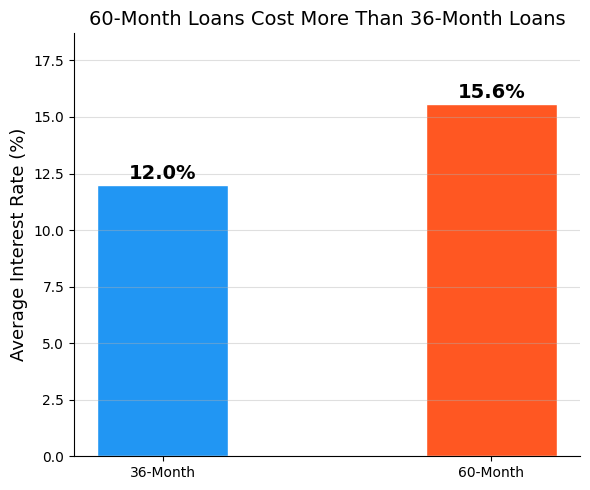

  36-month loans: 2,060,077 (70.4%)
  60-month loans: 865,415 (29.6%)


In [7]:

#block
# VIZ 2: Average Interest Rate by Loan Term
# Two bars, that's it
#block
plot_df = df[['term', 'int_rate']].dropna().copy()
plot_df['int_rate_pct'] = plot_df['int_rate'] * 100
plot_df['term_clean'] = plot_df['term'].astype(str).str.extract(r'(\d+)').astype(float)

summary = plot_df.groupby('term_clean')['int_rate_pct'].mean().reset_index()
summary['label'] = summary['term_clean'].apply(lambda x: f'{x:.0f}-Month')

fig, ax = plt.subplots(figsize=(6, 5))
bars = ax.bar(summary['label'], summary['int_rate_pct'],
              color=['#2196F3', '#FF5722'], width=0.4, edgecolor='white')

for bar, val in zip(bars, summary['int_rate_pct']):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.1,
            f'{val:.1f}%', ha='center', va='bottom', fontsize=14, fontweight='bold')

ax.set_ylabel('Average Interest Rate (%)', fontsize=13)
ax.set_title('60-Month Loans Cost More Than 36-Month Loans', fontsize=14)
ax.set_ylim(0, summary['int_rate_pct'].max() * 1.2)
ax.grid(True, axis='y', alpha=0.4)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.savefig('viz2_term_vs_rate.png', dpi=150, bbox_inches='tight')
plt.show()

counts = plot_df.groupby('term_clean').size()
for t, n in counts.items():
    print(f"  {t:.0f}-month loans: {n:,} ({n/len(plot_df)*100:.1f}%)")


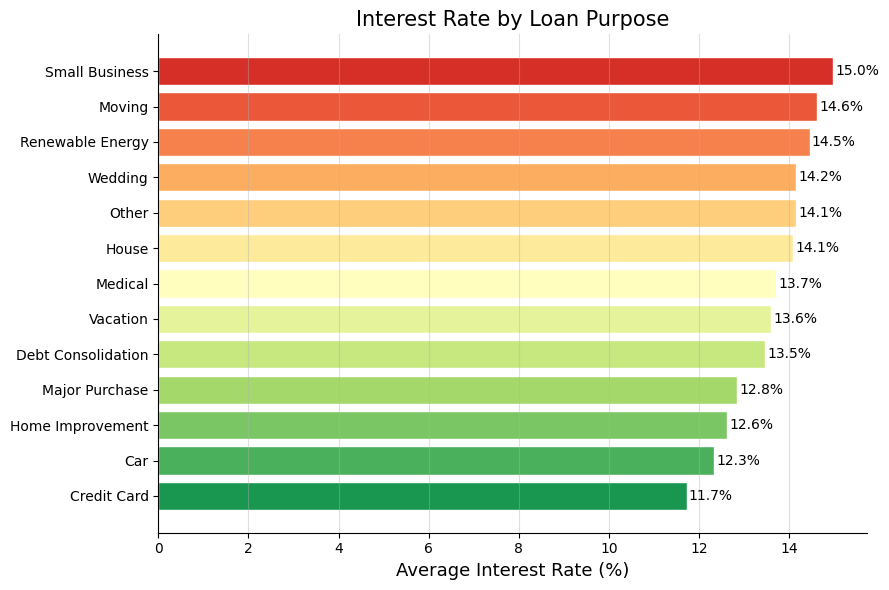

In [8]:

#block
# VIZ 3: Average Interest Rate by Loan Purpose
# Horizontal bar chart, sorted lowest to highest
#block
plot_df = df[['purpose', 'int_rate']].dropna().copy()
plot_df['int_rate_pct'] = plot_df['int_rate'] * 100

summary = (plot_df.groupby('purpose', observed=True)['int_rate_pct']
           .agg(mean='mean', count='count')
           .query('count >= 1000')
           .sort_values('mean'))

# Clean up category names for display
summary.index = (summary.index.astype(str)
                 .str.replace('_', ' ')
                 .str.title())

fig, ax = plt.subplots(figsize=(9, 6))

colors = plt.cm.RdYlGn_r(np.linspace(0.1, 0.9, len(summary)))
bars = ax.barh(summary.index, summary['mean'], color=colors, edgecolor='white')

for bar, val in zip(bars, summary['mean']):
    ax.text(val + 0.05, bar.get_y() + bar.get_height() / 2,
            f'{val:.1f}%', va='center', fontsize=10)

ax.set_xlabel('Average Interest Rate (%)', fontsize=13)
ax.set_title('Interest Rate by Loan Purpose', fontsize=15)
ax.grid(True, axis='x', alpha=0.4)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.savefig('viz3_purpose_vs_rate.png', dpi=150, bbox_inches='tight')
plt.show()


---
## Machine Learning: Predicting Interest Rates
### Pipeline: Feature Engineering → Multi-Model Race → SHAP Explainability → Borrower Simulator

In [9]:

#block
# STEP 1: FEATURE ENGINEERING
# Building smarter signals from raw data
#block
import warnings
warnings.filterwarnings('ignore')
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import lightgbm as lgb

print("Engineering features...")

ml = df.copy()

# --- Target (convert to percentage points) ---
ml['target'] = ml['int_rate'].astype(float) * 100

# --- FICO midpoint (single signal instead of two correlated cols) ---
ml['fico_mid'] = (ml['fico_range_low'].astype(float) + ml['fico_range_high'].astype(float)) / 2

# --- Credit age in years (how long they've had credit) ---
ml['issue_year'] = pd.to_datetime(ml['issue_d'], errors='coerce').dt.year if 'issue_d' in ml.columns else 2015
ml['earliest_cr_year'] = pd.to_datetime(ml['earliest_cr_line'], errors='coerce').dt.year
ml['credit_age_years'] = ml['issue_year'] - ml['earliest_cr_year']
ml['credit_age_years'] = ml['credit_age_years'].clip(0, 60)

# --- Loan-to-income ratio (affordability signal) ---
ml['loan_to_income'] = ml['loan_amnt'].astype(float) / (ml['annual_inc'].astype(float).clip(lower=1))
ml['loan_to_income'] = ml['loan_to_income'].clip(upper=10)

# --- Monthly payment burden (estimated installment / monthly income) ---
ml['monthly_income'] = ml['annual_inc'].astype(float) / 12

# --- DTI risk tier ---
dti = ml['dti'].astype(float)
ml['dti_tier'] = pd.cut(dti, bins=[-1, 10, 20, 30, 40, 999],
                         labels=['low', 'moderate', 'high', 'very_high', 'extreme'])

# --- FICO risk bucket ---
ml['fico_bucket'] = pd.cut(ml['fico_mid'],
                            bins=[0, 580, 620, 660, 700, 740, 780, 999],
                            labels=['deep_subprime', 'subprime', 'near_prime',
                                    'prime', 'prime_plus', 'super_prime', 'elite'])

# --- Term as numeric (36 or 60) ---
ml['term_months'] = ml['term'].astype(str).str.extract(r'(\d+)').astype(float)

# --- Employment length as numeric ---
emp_map = {'< 1 year': 0, '1 year': 1, '2 years': 2, '3 years': 3, '4 years': 4,
           '5 years': 5, '6 years': 6, '7 years': 7, '8 years': 8, '9 years': 9, '10+ years': 10}
ml['emp_length_num'] = ml['emp_length'].astype(str).map(emp_map).fillna(-1)

# --- Derogatory record flag (any negative mark) ---
ml['has_derogatories'] = (
    (ml['delinq_2yrs'].astype(float) > 0) |
    (ml['pub_rec'].astype(float) > 0) |
    (ml['pub_rec_bankruptcies'].astype(float) > 0)
).astype(int)

# --- State risk score (median rate by state) ---
state_risk = ml.groupby('addr_state', observed=True)['target'].median().rename('state_risk_score')
ml = ml.join(state_risk, on='addr_state')

# --- Purpose risk score (median rate by purpose) ---
purpose_risk = ml.groupby('purpose', observed=True)['target'].median().rename('purpose_risk_score')
ml = ml.join(purpose_risk, on='purpose')

# --- Revolving utilization risk ---
ml['revol_util_float'] = ml['revol_util'].astype(float)
ml['high_util_flag'] = (ml['revol_util_float'] > 75).astype(int)

# --- Log-transform skewed financial features ---
ml['log_annual_inc'] = np.log1p(ml['annual_inc'].astype(float))
ml['log_revol_bal'] = np.log1p(ml['revol_bal'].astype(float))
ml['log_loan_amnt'] = np.log1p(ml['loan_amnt'].astype(float))

print("Feature engineering complete.")
print(f"Dataset shape: {ml.shape}")
print("\nNew features created:")
new_feats = ['fico_mid', 'credit_age_years', 'loan_to_income', 'dti_tier', 'fico_bucket',
             'term_months', 'emp_length_num', 'has_derogatories', 'state_risk_score',
             'purpose_risk_score', 'high_util_flag', 'log_annual_inc', 'log_revol_bal', 'log_loan_amnt']
for f in new_feats:
    print(f"  ✓ {f}")


Engineering features...
Feature engineering complete.
Dataset shape: (2925492, 160)

New features created:
  ✓ fico_mid
  ✓ credit_age_years
  ✓ loan_to_income
  ✓ dti_tier
  ✓ fico_bucket
  ✓ term_months
  ✓ emp_length_num
  ✓ has_derogatories
  ✓ state_risk_score
  ✓ purpose_risk_score
  ✓ high_util_flag
  ✓ log_annual_inc
  ✓ log_revol_bal
  ✓ log_loan_amnt


In [10]:

#block
# STEP 2: PREPARE MODEL DATASET
# Select final features, encode categoricals, split data
#block

FEATURES = [
    # Core credit signals
    'fico_mid', 'dti', 'revol_util_float', 'credit_age_years',
    'delinq_2yrs', 'inq_last_6mths', 'open_acc', 'pub_rec',
    'pub_rec_bankruptcies', 'mort_acc',
    # Loan features
    'loan_amnt', 'term_months',
    # Financial capacity
    'log_annual_inc', 'log_revol_bal', 'log_loan_amnt', 'loan_to_income',
    # Employment
    'emp_length_num',
    # Engineered risk signals
    'has_derogatories', 'high_util_flag',
    'state_risk_score', 'purpose_risk_score',
    # Categorical (LightGBM handles natively)
    'home_ownership', 'verification_status', 'application_type',
    'purpose', 'addr_state',
]

TARGET = 'target'

# --- Drop rows missing target or key features ---
model_df = ml[FEATURES + [TARGET]].dropna(subset=[TARGET, 'fico_mid', 'dti'])
print(f"Model dataset: {model_df.shape[0]:,} rows × {len(FEATURES)} features")

# --- Encode categoricals as pandas category (LightGBM native support) ---
cat_cols = ['home_ownership', 'verification_status', 'application_type', 'purpose', 'addr_state']
for c in cat_cols:
    model_df[c] = model_df[c].astype(str).astype('category')

# --- Train / Validation / Test split (70/15/15) ---
X = model_df[FEATURES]
y = model_df[TARGET]

X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.30, random_state=42)
X_val,   X_test, y_val,   y_test  = train_test_split(X_temp, y_temp, test_size=0.50, random_state=42)

print(f"\nSplit sizes:")
print(f"  Train : {len(X_train):>9,} rows ({len(X_train)/len(X)*100:.0f}%)")
print(f"  Val   : {len(X_val):>9,} rows ({len(X_val)/len(X)*100:.0f}%)")
print(f"  Test  : {len(X_test):>9,} rows ({len(X_test)/len(X)*100:.0f}%)")

def eval_metrics(name, y_true, y_pred):
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = mean_squared_error(y_true, y_pred) ** 0.5
    r2   = r2_score(y_true, y_pred)
    print(f"  {name:<22}  MAE={mae:.3f}%  RMSE={rmse:.3f}%  R²={r2:.4f}")
    return {'model': name, 'MAE': mae, 'RMSE': rmse, 'R2': r2}

results = []


Model dataset: 2,925,492 rows × 26 features

Split sizes:
  Train : 2,047,844 rows (70%)
  Val   :   438,824 rows (15%)
  Test  :   438,824 rows (15%)


In [ ]:
# STEP 3: BASELINE — Mean & Linear Regression
from sklearn.linear_model import Ridge
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

print("=" * 60)
print("MODEL RACE — Test Set Performance")
print("=" * 60)

#Baseline: always predict the mean ---
baseline_pred = np.full(len(y_test), y_train.mean())
results.append(eval_metrics("Baseline (mean)", y_test, baseline_pred))

# --- Ridge Regression (on numeric features only for speed) ---
num_feats = [f for f in FEATURES if f not in cat_cols]

num_pipeline = Pipeline([
    ('impute', SimpleImputer(strategy='median')),
    ('scale',  StandardScaler()),
])
cat_pipeline = Pipeline([
    ('impute', SimpleImputer(strategy='most_frequent')),
    ('ohe',    OneHotEncoder(handle_unknown='ignore', sparse_output=False)),
])
preprocessor = ColumnTransformer([
    ('num', num_pipeline, num_feats),
    ('cat', cat_pipeline, cat_cols),
])

ridge_pipe = Pipeline([
    ('prep',  preprocessor),
    ('model', Ridge(alpha=1.0)),
])

# Use a sample for ridge (still large)
sample_idx = X_train.sample(n=200_000, random_state=42).index
ridge_pipe.fit(X_train.loc[sample_idx], y_train.loc[sample_idx])
ridge_pred = ridge_pipe.predict(X_test)
results.append(eval_metrics("Ridge Regression", y_test, ridge_pred))


MODEL RACE — Test Set Performance
  Baseline (mean)         MAE=3.845%  RMSE=4.858%  R²=-0.0000
  Ridge Regression        MAE=2.861%  RMSE=3.753%  R²=0.4033


In [12]:

#block
# STEP 4: LIGHTGBM — Champion Model
# Handles 2.9M rows natively, categorical features, missing values
#block

print("\nTraining LightGBM on full training set (~2M rows)...")

lgb_train = lgb.Dataset(X_train, label=y_train, categorical_feature=cat_cols, free_raw_data=False)
lgb_val   = lgb.Dataset(X_val,   label=y_val,   categorical_feature=cat_cols, free_raw_data=False, reference=lgb_train)

params = {
    'objective':        'regression',
    'metric':           'rmse',
    'learning_rate':    0.05,
    'num_leaves':       127,
    'min_child_samples': 50,
    'feature_fraction': 0.8,
    'bagging_fraction': 0.8,
    'bagging_freq':     5,
    'reg_alpha':        0.1,
    'reg_lambda':       0.1,
    'verbose':          -1,
    'n_jobs':           -1,
}

callbacks = [
    lgb.early_stopping(stopping_rounds=30, verbose=False),
    lgb.log_evaluation(period=50),
]

lgb_model = lgb.train(
    params,
    lgb_train,
    num_boost_round=500,
    valid_sets=[lgb_val],
    callbacks=callbacks,
)

lgb_pred = lgb_model.predict(X_test)
results.append(eval_metrics("LightGBM", y_test, lgb_pred))

print(f"\nBest iteration: {lgb_model.best_iteration}")



Training LightGBM on full training set (~2M rows)...
[50]	valid_0's rmse: 3.67674
[100]	valid_0's rmse: 3.5887
[150]	valid_0's rmse: 3.55643
[200]	valid_0's rmse: 3.53668
[250]	valid_0's rmse: 3.52534
[300]	valid_0's rmse: 3.51834
[350]	valid_0's rmse: 3.51494
[400]	valid_0's rmse: 3.51246
[450]	valid_0's rmse: 3.51067
[500]	valid_0's rmse: 3.50886
  LightGBM                MAE=2.630%  RMSE=3.499%  R²=0.4814

Best iteration: 500



FINAL LEADERBOARD
           model      MAE     RMSE            R2
        LightGBM 2.630085 3.498576  4.813507e-01
Ridge Regression 2.861150 3.752661  4.032810e-01
 Baseline (mean) 3.845272 4.857967 -6.508873e-07


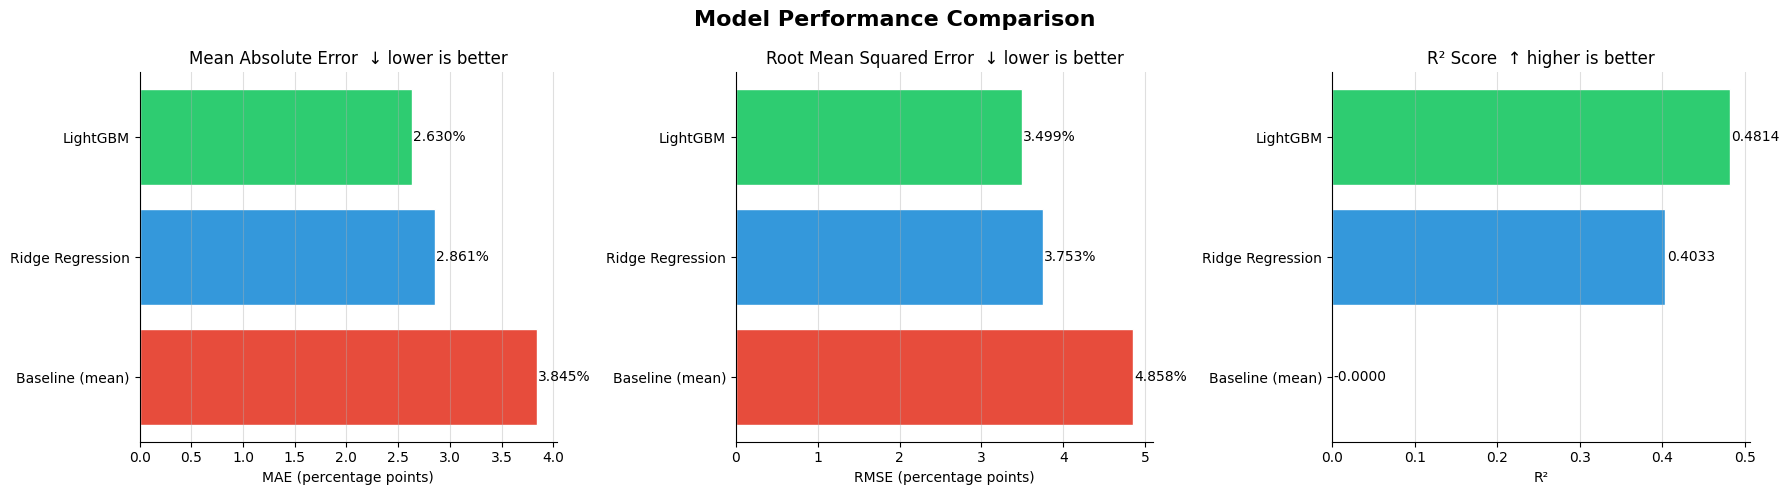

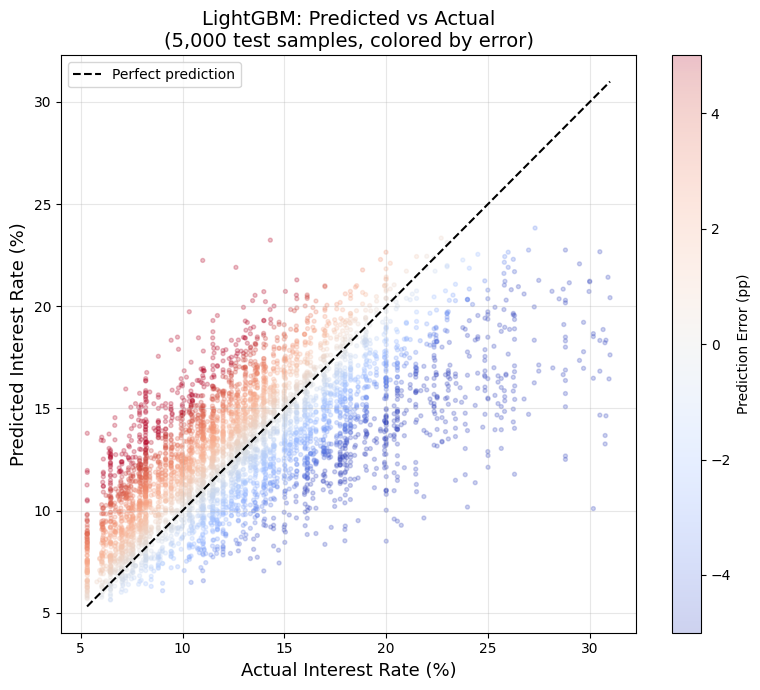

In [13]:

#block
# STEP 5: MODEL COMPARISON DASHBOARD
# Visual leaderboard + predicted vs actual plot
#block

results_df = pd.DataFrame(results)
print("\n" + "=" * 60)
print("FINAL LEADERBOARD")
print("=" * 60)
print(results_df.sort_values('R2', ascending=False).to_string(index=False))

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Model Performance Comparison', fontsize=16, fontweight='bold')

colors = ['#e74c3c', '#3498db', '#2ecc71'][:len(results_df)]

# MAE bar
axes[0].barh(results_df['model'], results_df['MAE'], color=colors, edgecolor='white')
axes[0].set_xlabel('MAE (percentage points)')
axes[0].set_title('Mean Absolute Error  ↓ lower is better')
axes[0].grid(True, axis='x', alpha=0.4)
for i, v in enumerate(results_df['MAE']):
    axes[0].text(v + 0.01, i, f'{v:.3f}%', va='center', fontsize=10)

# RMSE bar
axes[1].barh(results_df['model'], results_df['RMSE'], color=colors, edgecolor='white')
axes[1].set_xlabel('RMSE (percentage points)')
axes[1].set_title('Root Mean Squared Error  ↓ lower is better')
axes[1].grid(True, axis='x', alpha=0.4)
for i, v in enumerate(results_df['RMSE']):
    axes[1].text(v + 0.01, i, f'{v:.3f}%', va='center', fontsize=10)

# R² bar
axes[2].barh(results_df['model'], results_df['R2'], color=colors, edgecolor='white')
axes[2].set_xlabel('R²')
axes[2].set_title('R² Score  ↑ higher is better')
axes[2].grid(True, axis='x', alpha=0.4)
for i, v in enumerate(results_df['R2']):
    axes[2].text(v + 0.002, i, f'{v:.4f}', va='center', fontsize=10)

for ax in axes:
    ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.savefig('model_leaderboard.png', dpi=150, bbox_inches='tight')
plt.show()

# --- Predicted vs Actual (LightGBM, sample 5k for clarity) ---
sample_size = 5000
idx = np.random.choice(len(y_test), sample_size, replace=False)
y_sample = np.array(y_test)[idx]
p_sample  = lgb_pred[idx]

fig, ax = plt.subplots(figsize=(8, 7))
sc = ax.scatter(y_sample, p_sample, alpha=0.25, s=8, c=p_sample - y_sample,
                cmap='coolwarm', vmin=-5, vmax=5)
plt.colorbar(sc, ax=ax, label='Prediction Error (pp)')
ax.plot([y_sample.min(), y_sample.max()],
        [y_sample.min(), y_sample.max()], 'k--', linewidth=1.5, label='Perfect prediction')
ax.set_xlabel('Actual Interest Rate (%)', fontsize=13)
ax.set_ylabel('Predicted Interest Rate (%)', fontsize=13)
ax.set_title('LightGBM: Predicted vs Actual\n(5,000 test samples, colored by error)', fontsize=14)
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('predicted_vs_actual.png', dpi=150, bbox_inches='tight')
plt.show()


Computing SHAP values (sample of 2,000 rows)...


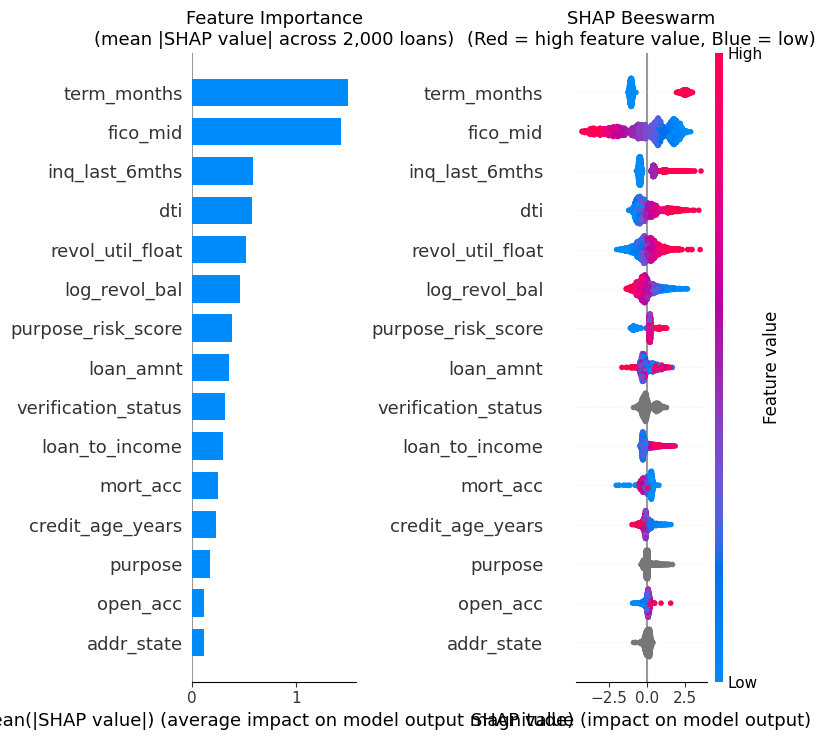


Top 5 rate DRIVERS (push rate up):
term_months         1.497090
fico_mid            1.431022
inq_last_6mths      0.582006
dti                 0.572028
revol_util_float    0.514549


In [14]:
#block
# STEP 6: SHAP EXPLAINABILITY
# What actually drives the predicted interest rate?
#block
import shap

print("Computing SHAP values (sample of 2,000 rows)...")

# Use a small sample for SHAP — sufficient for reliable explanations
shap_sample = X_test.sample(n=2000, random_state=42)

explainer   = shap.TreeExplainer(lgb_model)
shap_values = explainer.shap_values(shap_sample)

# --- Plot 1: Feature Importance (mean |SHAP|) ---
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

plt.sca(axes[0])
shap.summary_plot(
    shap_values, shap_sample,
    plot_type="bar",
    max_display=15,
    show=False,
)
axes[0].set_title("Feature Importance\n(mean |SHAP value| across 2,000 loans)", fontsize=13)

# --- Plot 2: SHAP Beeswarm — direction & magnitude ---
plt.sca(axes[1])
shap.summary_plot(
    shap_values, shap_sample,
    max_display=15,
    show=False,
)
axes[1].set_title("SHAP Beeswarm\n(Red = high feature value, Blue = low)", fontsize=13)

plt.tight_layout()
plt.savefig("shap_summary.png", dpi=150, bbox_inches="tight")
plt.show()

print("\nTop 5 rate DRIVERS (push rate up):")
mean_shap = pd.Series(np.abs(shap_values).mean(axis=0), index=FEATURES).sort_values(ascending=False)
print(mean_shap.head(5).to_string())


In [15]:

#block
# STEP 7: BUSINESS INSIGHTS DASHBOARD
# How much does each factor cost a borrower in real dollars?
#block

# Median loan amount for dollar-impact calculations
median_loan = float(ml['loan_amnt'].median())
median_term = 36  # months

def rate_to_total_interest(rate_pct, principal=median_loan, term=median_term):
    """Total interest paid over loan life at a given annual rate."""
    r = rate_pct / 100 / 12
    if r == 0:
        return 0
    payment = principal * r / (1 - (1 + r) ** -term)
    return payment * term - principal

print(f"Median loan: ${median_loan:,.0f} over {median_term} months\n")
print(f"{'Rate':>6}  {'Monthly Pmt':>12}  {'Total Interest':>15}  {'vs 10% rate':>12}")
print("─" * 55)
for rate in [6, 8, 10, 12, 14, 16, 18, 20, 24, 28]:
    r = rate / 100 / 12
    pmt = median_loan * r / (1 - (1 + r) ** -median_term)
    total_int = pmt * median_term - median_loan
    delta = total_int - rate_to_total_interest(10)
    sign = '+' if delta >= 0 else ''
    print(f"{rate:5}%  ${pmt:>11,.2f}  ${total_int:>14,.0f}  {sign}${delta:>10,.0f}")

# --- Sensitivity: FICO improvement ---
print("\n── FICO Score Impact ─────────────────────────────────────")
fico_bins = ['deep_subprime', 'subprime', 'near_prime', 'prime', 'prime_plus', 'super_prime', 'elite']
fico_avg_rate = (
    ml.groupby('fico_bucket', observed=True)['target']
    .mean()
    .reindex(fico_bins)
    .dropna()
)
for bucket, rate in fico_avg_rate.items():
    total_int = rate_to_total_interest(rate)
    print(f"  {bucket:<16}  avg rate={rate:.1f}%  total interest=${total_int:>8,.0f}")

# --- Savings from improving FICO ---
if 'subprime' in fico_avg_rate.index and 'prime' in fico_avg_rate.index:
    savings = rate_to_total_interest(fico_avg_rate['subprime']) - rate_to_total_interest(fico_avg_rate['prime'])
    print(f"\n  Improving from subprime → prime saves ${savings:,.0f} in interest on a ${median_loan:,.0f} loan!")


Median loan: $13,000 over 36 months

  Rate   Monthly Pmt   Total Interest   vs 10% rate
───────────────────────────────────────────────────────
    6%  $     395.49  $         1,237  $      -864
    8%  $     407.37  $         1,665  $      -436
   10%  $     419.47  $         2,101  +$         0
   12%  $     431.79  $         2,544  +$       443
   14%  $     444.31  $         2,995  +$       894
   16%  $     457.04  $         3,453  +$     1,352
   18%  $     469.98  $         3,919  +$     1,818
   20%  $     483.13  $         4,393  +$     2,292
   24%  $     510.03  $         5,361  +$     3,260
   28%  $     537.73  $         6,358  +$     4,257

── FICO Score Impact ─────────────────────────────────────
  subprime          avg rate=17.8%  total interest=$   3,861
  near_prime        avg rate=15.1%  total interest=$   3,252
  prime             avg rate=14.6%  total interest=$   3,126
  prime_plus        avg rate=12.0%  total interest=$   2,540
  super_prime       avg rate=9.7%

In [16]:

#block
# STEP 8: BORROWER RATE SIMULATOR
# "What rate would I get?" — interactive function
#block

def predict_rate(
    fico_score      = 700,
    annual_income   = 75_000,
    loan_amount     = 15_000,
    term_months     = 36,
    dti             = 18.0,
    revol_util      = 30.0,
    delinq_2yrs     = 0,
    inq_last_6mths  = 1,
    open_acc        = 8,
    pub_rec         = 0,
    pub_rec_bankruptcies = 0,
    mort_acc        = 1,
    revol_bal       = 8_000,
    emp_length_yrs  = 5,
    home_ownership  = 'RENT',
    verification_status = 'Verified',
    purpose         = 'debt_consolidation',
    application_type = 'Individual',
    addr_state      = 'CA',
    verbose         = True,
):
    """
    Predict the interest rate for a borrower profile using the trained LightGBM model.
    All inputs are borrower characteristics known at loan origination.
    Returns predicted annual interest rate as a percentage.
    """
    # Engineered features
    fico_mid_val       = fico_score + 2.0          # approximate midpoint
    credit_age         = 12                         # assume 12 years if not provided
    loan_to_inc        = min(loan_amount / max(annual_income, 1), 10)
    has_derogs         = int(delinq_2yrs > 0 or pub_rec > 0 or pub_rec_bankruptcies > 0)
    high_util          = int(revol_util > 75)
    log_inc            = np.log1p(annual_income)
    log_revol          = np.log1p(revol_bal)
    log_loan           = np.log1p(loan_amount)

    # Look up risk scores from the training data
    state_score   = ml.groupby('addr_state',   observed=True)['target'].median().get(addr_state,   ml['target'].median())
    purpose_score = ml.groupby('purpose',      observed=True)['target'].median().get(purpose,      ml['target'].median())

    row = pd.DataFrame([{
        'fico_mid':              fico_mid_val,
        'dti':                   dti,
        'revol_util_float':      revol_util,
        'credit_age_years':      credit_age,
        'delinq_2yrs':           delinq_2yrs,
        'inq_last_6mths':        inq_last_6mths,
        'open_acc':              open_acc,
        'pub_rec':               pub_rec,
        'pub_rec_bankruptcies':  pub_rec_bankruptcies,
        'mort_acc':              mort_acc,
        'loan_amnt':             loan_amount,
        'term_months':           term_months,
        'log_annual_inc':        log_inc,
        'log_revol_bal':         log_revol,
        'log_loan_amnt':         log_loan,
        'loan_to_income':        loan_to_inc,
        'emp_length_num':        emp_length_yrs,
        'has_derogatories':      has_derogs,
        'high_util_flag':        high_util,
        'state_risk_score':      state_score,
        'purpose_risk_score':    purpose_score,
        'home_ownership':        home_ownership,
        'verification_status':   verification_status,
        'application_type':      application_type,
        'purpose':               purpose,
        'addr_state':            addr_state,
    }])

    for c in cat_cols:
        row[c] = row[c].astype('category')

    predicted_rate = lgb_model.predict(row)[0]
    predicted_rate = float(np.clip(predicted_rate, 5.0, 36.0))

    if verbose:
        r = predicted_rate / 100 / 12
        monthly_pmt = loan_amount * r / (1 - (1 + r) ** -term_months)
        total_interest = monthly_pmt * term_months - loan_amount

        # Rate tier label
        if predicted_rate < 8:    tier, color = "Excellent", "\033[92m"
        elif predicted_rate < 12: tier, color = "Good",      "\033[94m"
        elif predicted_rate < 16: tier, color = "Average",   "\033[93m"
        elif predicted_rate < 22: tier, color = "High",      "\033[91m"
        else:                     tier, color = "Very High", "\033[31m"
        reset = "\033[0m"

        print("─" * 50)
        print(f"  BORROWER RATE ESTIMATE")
        print("─" * 50)
        print(f"  Predicted Rate  : {color}{predicted_rate:.2f}% ({tier}){reset}")
        print(f"  Monthly Payment : ${monthly_pmt:,.2f}")
        print(f"  Total Interest  : ${total_interest:,.0f} over {term_months} months")
        print(f"  Total Cost      : ${loan_amount + total_interest:,.0f}")
        print("─" * 50)
        print(f"  Key inputs: FICO={fico_score}, DTI={dti}%, RevUtil={revol_util}%")
        print(f"              Income=${annual_income:,}, Loan=${loan_amount:,}, Term={term_months}mo")
        print("─" * 50)

    return predicted_rate


# ── Example borrowers ──────────────────────────────────────
print("EXAMPLE 1: Prime borrower — excellent credit")
predict_rate(fico_score=760, annual_income=120_000, loan_amount=20_000,
             dti=10, revol_util=15, delinq_2yrs=0, purpose='home_improvement',
             home_ownership='MORTGAGE', verification_status='Verified')

print("\nEXAMPLE 2: Subprime borrower — poor credit, high debt")
predict_rate(fico_score=620, annual_income=45_000, loan_amount=15_000,
             dti=35, revol_util=85, delinq_2yrs=2, pub_rec=1,
             purpose='debt_consolidation', home_ownership='RENT',
             verification_status='Not Verified')

print("\nEXAMPLE 3: Average borrower — middle-of-road profile")
predict_rate(fico_score=700, annual_income=75_000, loan_amount=12_000,
             dti=20, revol_util=40, delinq_2yrs=0, purpose='car',
             home_ownership='RENT', verification_status='Source Verified')


EXAMPLE 1: Prime borrower — excellent credit
──────────────────────────────────────────────────
  BORROWER RATE ESTIMATE
──────────────────────────────────────────────────
  Predicted Rate  : 10.01% (Good)
  Monthly Payment : $645.40
  Total Interest  : $3,234 over 36 months
  Total Cost      : $23,234
──────────────────────────────────────────────────
  Key inputs: FICO=760, DTI=10%, RevUtil=15%
              Income=$120,000, Loan=$20,000, Term=36mo
──────────────────────────────────────────────────

EXAMPLE 2: Subprime borrower — poor credit, high debt
──────────────────────────────────────────────────
  BORROWER RATE ESTIMATE
──────────────────────────────────────────────────
  Predicted Rate  : 17.72% (High)
  Monthly Payment : $540.20
  Total Interest  : $4,447 over 36 months
  Total Cost      : $19,447
──────────────────────────────────────────────────
  Key inputs: FICO=620, DTI=35%, RevUtil=85%
              Income=$45,000, Loan=$15,000, Term=36mo
──────────────────────────────

14.246597938865342

Base profile rate: 17.32%
Improvement                               New Rate    Savings  $/mo saved
─────────────────────────────────────────────────────────────────────────
  Raise FICO 680 → 720                     13.72%  ↓  3.60pp  $  +26.54/mo  ($   +955 total)
  Raise FICO 680 → 760                     12.04%  ↓  5.28pp  $  +38.66/mo  ($  +1392 total)
  Lower DTI 22% → 10%                      17.09%  ↓  0.23pp  $   +1.72/mo  ($    +62 total)
  Lower RevUtil 55% → 20%                  17.32%  ↑  0.00pp  $   +0.00/mo  ($     +0 total)
  Get income verified                      16.88%  ↓  0.44pp  $   +3.30/mo  ($   +119 total)
  Switch to 36mo (already is)              17.32%  ↑  0.00pp  $   +0.00/mo  ($     +0 total)
  All improvements combined                11.74%  ↓  5.58pp  $  +40.80/mo  ($  +1469 total)


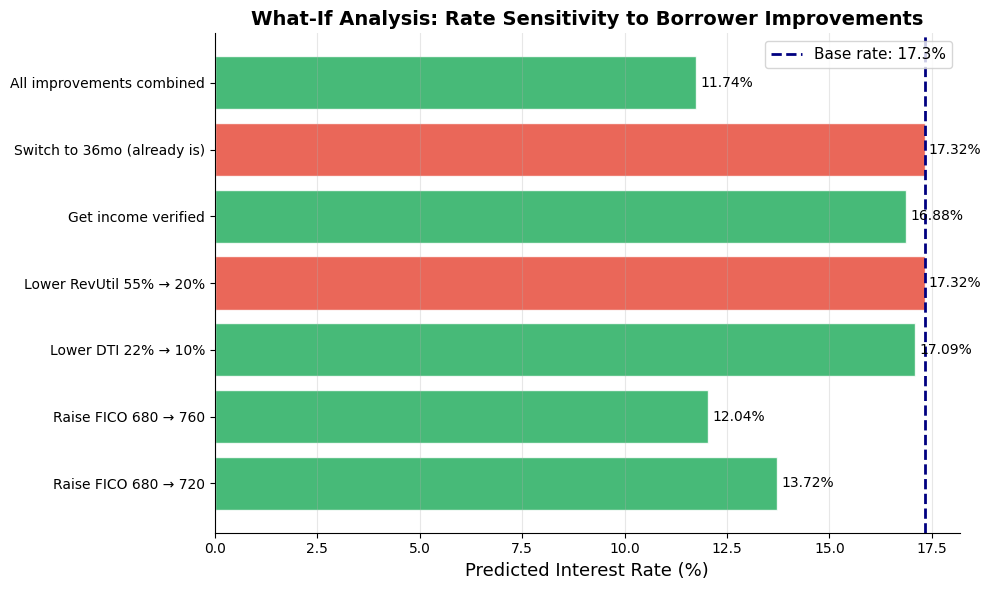

In [17]:

#block
# STEP 9: "WHAT-IF" SENSITIVITY ANALYSIS
# How much does improving one factor reduce your rate?
#block

base_profile = dict(
    fico_score=680, annual_income=65_000, loan_amount=15_000,
    term_months=36, dti=22, revol_util=55, delinq_2yrs=0,
    inq_last_6mths=2, open_acc=7, pub_rec=0, pub_rec_bankruptcies=0,
    mort_acc=0, revol_bal=6_000, emp_length_yrs=4,
    home_ownership='RENT', verification_status='Not Verified',
    purpose='debt_consolidation', application_type='Individual',
    addr_state='TX', verbose=False,
)

base_rate = predict_rate(**base_profile)
print(f"Base profile rate: {base_rate:.2f}%")
print(f"{'Improvement':<40} {'New Rate':>9}  {'Savings':>9}  {'$/mo saved':>10}")
print("─" * 73)

scenarios = [
    ("Raise FICO 680 → 720",         {'fico_score': 720}),
    ("Raise FICO 680 → 760",         {'fico_score': 760}),
    ("Lower DTI 22% → 10%",          {'dti': 10}),
    ("Lower RevUtil 55% → 20%",      {'revol_util': 20}),
    ("Get income verified",          {'verification_status': 'Verified'}),
    ("Switch to 36mo (already is)",  {'term_months': 36}),
    ("All improvements combined",    {'fico_score': 760, 'dti': 10, 'revol_util': 20,
                                      'verification_status': 'Verified'}),
]

for label, overrides in scenarios:
    profile = {**base_profile, **overrides}
    new_rate = predict_rate(**profile)
    rate_diff = base_rate - new_rate

    # Dollar savings on monthly payment
    def monthly_pmt(rate, loan=15_000, term=36):
        r = rate / 100 / 12
        return loan * r / (1 - (1 + r) ** -term)

    pmt_savings = monthly_pmt(base_rate) - monthly_pmt(new_rate)
    total_savings = pmt_savings * 36

    direction = "↓" if rate_diff > 0 else "↑"
    print(f"  {label:<38} {new_rate:>7.2f}%  {direction}{abs(rate_diff):>6.2f}pp  ${pmt_savings:>+8.2f}/mo  (${total_savings:>+7.0f} total)")

# ── Visualize "what-if" ─────────────────────────────────────
scenario_labels = [s[0] for s in scenarios]
scenario_rates  = []
for label, overrides in scenarios:
    profile = {**base_profile, **overrides}
    scenario_rates.append(predict_rate(**profile))

fig, ax = plt.subplots(figsize=(10, 6))
colors_bar = ['#27ae60' if r < base_rate else '#e74c3c' for r in scenario_rates]
bars = ax.barh(scenario_labels, scenario_rates, color=colors_bar, edgecolor='white', alpha=0.85)
ax.axvline(base_rate, color='navy', linestyle='--', linewidth=2, label=f'Base rate: {base_rate:.1f}%')

for bar, val in zip(bars, scenario_rates):
    ax.text(val + 0.1, bar.get_y() + bar.get_height() / 2,
            f'{val:.2f}%', va='center', fontsize=10)

ax.set_xlabel('Predicted Interest Rate (%)', fontsize=13)
ax.set_title('What-If Analysis: Rate Sensitivity to Borrower Improvements', fontsize=14, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(True, axis='x', alpha=0.3)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.savefig('whatif_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
